# **Business Problem**

The retailer struggles with:

**Suboptimal Pricing:** Setting prices too high (reducing sales volume) or too low (eroding profits).

**Competitor Pressure:** Losing market share due to uncompetitive pricing against comp_1, comp_2, or comp_3.

**Demand Uncertainty:** Inability to predict how price changes affect sales volume (qty).

**Cost Management:** High freight_price eating into margins without corresponding sales growth.

**Objective**: Use the dataset to build a price optimization model that recommends prices to:

**Maximize profit:** (unit_price - cost) × qty.

Maintain competitive positioning against comp_1, comp_2, comp_3.

Account for seasonality, holidays, and product attributes.





Retail price optimization involves determining the optimal selling price for products or services to maximize revenue and profit.
Optimizing retail prices means finding the perfect balance between the price you charge for your products and the number of products you can sell at that price.

The ultimate aim is to charge a price that helps you make the most money and attracts enough customers to buy your products. It involves using data and pricing strategies to find the right price that maximizes your sales and profits while keeping customers happy.

# **Project Introduction**
This project aims to address critical challenges in retail pricing and demand forecasting by leveraging historical sales data. Retailers often struggle to balance competitive pricing, profit margins, and customer demand, especially in dynamic markets with seasonal fluctuations and competitor pressure. By analyzing transactional data across diverse product categories, this project seeks to uncover actionable insights to optimize pricing strategies, improve inventory planning, and enhance profitability.


**Dataset Information**

The dataset contains 676 entries and 30 features related to retail product pricing, including product details, sales metrics, competitor prices, and time-based attributes.

**Filename:** retail_price.csv

**Records:** Multiple products across categories (e.g., bed_bath_table, garden_tools, health_beauty, watches_gifts).

**Key Features:**

**Product Attributes:**

product_id, product_category_name,
product_name_lenght, product_description_lenght, product_photos_qty

product_weight_g, product_score (customer rating).

**Sales & Pricing:**

month_year, qty (units sold), total_price (revenue), unit_price, freight_price.

lag_price: Price from the previous period for trend analysis.

**Competitor Data:**

comp_1, comp_2, comp_3: Competitors’ prices.

ps1, ps2, ps3: Competitors’ product scores.

fp1, fp2, fp3: Competitors’ freight prices.

**Contextual Features:**

**Temporal:** month, year, weekday, weekend, holiday.

**Behavioral**: customers (unique buyers), volume (sales volume).

**Target Variable**

**Primary Target:** qty (quantity sold)

Critical for calculating price elasticity and demand forecasting.

**Secondary Targets:**

**unit_price:** To analyze price thresholds and optimal pricing zones.

**total_price:** For revenue optimization.



importing all the necessary libraries for data Pre-processing, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# **Loading Dataset**

Loads a CSV file named retail_price.csv into a pandas DataFrame named larve_dataset.


In [2]:
larve_dataset = pd.read_csv("retail_price.csv")

In [3]:
larve_dataset.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


Displays the first 5 rows of the larve_dataset DataFrame.

Useful for an initial inspection of data structure, column names, and the type of values contained.

In [4]:
larve_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

Most features are numeric (float64, int64), with categorical columns like product_category_name and month_year.

The dataset includes 3 types of data:

Object (Categorical):

Float64 (Continuous/Numeric):



Now let’s have a look at the descriptive statistics of the data:

In [5]:
larve_dataset.describe()

,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,...,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,14.495562,1422.708728,20.682270,106.496800,48.720414,767.399408,1.994083,1847.498521,4.085503,81.028107,...,79.452054,4.159467,18.597610,92.930079,4.123521,18.620644,84.182642,4.002071,17.965007,107.399684
std,15.443421,1700.123100,10.081817,76.182972,9.420715,655.205015,1.420473,2274.808483,0.232021,62.055560,...,47.933358,0.121652,9.406537,49.481269,0.207189,6.424174,47.745789,0.233292,5.533256,76.974657
min,1.000000,19.900000,0.000000,19.900000,29.000000,100.000000,1.000000,100.000000,3.300000,1.000000,...,19.900000,3.700000,0.095439,19.900000,3.300000,4.410000,19.900000,3.500000,7.670000,19.850000
25%,4.000000,333.700000,14.761912,53.900000,40.000000,339.000000,1.000000,348.000000,3.900000,34.000000,...,49.910000,4.100000,13.826429,53.900000,4.100000,14.485000,53.785714,3.900000,15.042727,55.668750
50%,10.000000,807.890000,17.518472,89.900000,51.000000,501.000000,1.500000,950.000000,4.100000,62.000000,...,69.900000,4.200000,16.618984,89.990000,4.200000,16.811765,59.900000,4.000000,16.517110,89.900000
75%,18.000000,1887.322500,22.713558,129.990000,57.000000,903.000000,2.000000,1850.000000,4.200000,116.000000,...,104.256549,4.200000,19.732500,117.888889,4.200000,21.665238,99.990000,4.100000,19.447778,129.990000
max,122.000000,12095.000000,79.760000,364.000000,60.000000,3006.000000,8.000000,9750.000000,4.500000,339.000000,...,349.900000,4.500000,57.230000,349.900000,4.400000,57.230000,255.610000,4.400000,57.230000,364.000000


In [6]:
larve_dataset.isnull().sum()

,0
product_id,0
product_category_name,0
month_year,0
qty,0
total_price,0
freight_price,0
unit_price,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0


Missing Values: No missing values detected (larve_dataset.isnull().sum() shows all zeros).

In [7]:
larve_dataset.drop_duplicates(inplace=True)

Duplicates: Duplicates were dropped (larve_dataset.drop_duplicates()), though the dataset size remained unchanged, indicating no duplicates initially.



**Now let’s have a look at the distribution of the prices of the products:**

In [8]:
fig = px.histogram(larve_dataset,
                   x='total_price',
                   nbins=20,
                   title='Distribution of Total Price')
fig.show()

The price distribution is right-skewed, peaking at 2k (~350 products), with counts dropping sharply at higher prices (e.g., ~100-150 at 6k-8k, near zero at 12k). Most products are budget-friendly (2k-4k), suggesting a focus on affordability over premium pricing. High-priced items (8k+) are rare, indicating a potential niche or strategic emphasis on cost-conscious buyers.

**Now let’s have a look at the distribution of the unit prices using a box plot:**

In [9]:
fig = px.box(larve_dataset,
             y='unit_price',
             title='Box Plot of Unit Price')
fig.show()


**Central Tendency:** Median unit price is ~100-150 (midpoint of the data).

**Spread:** Middle 50% of products (IQR) range from ~50 to 250, showing moderate variability.

**Skew**: Right-skewed—most prices are low, but a few outliers reach 300-350 (likely premium items).

**Link to Total Prices**: High unit prices (300-350) don’t lead to high total prices (>8k), suggesting bulk purchases of cheaper items (e.g., 100-unit packs) dominate total spending.

**Key Takeaway:** Affordable unit prices drive volume sales, while premium-priced items remain niche.

**Now let’s have a look at the relationship between quantity and total prices:**

In [10]:
fig = px.scatter(larve_dataset,
                 x='qty',
                 y='total_price',
                 title='Quantity vs Total Price', trendline="ols")
fig.show()

**Quantity vs. Total Price**

The scatter plot shows a clear positive relationship between quantity and total price, reflecting a volume-based pricing model. Outliers suggest premium items (high price at low quantity) and bulk discounts (lower price at high quantity). This indicates a pricing strategy that balances standard volume pricing with selective premium offerings.

**Now let’s have a look at the average total prices by product categories:**

In [11]:
fig = px.bar(larve_dataset, x='product_category_name',
             y='total_price',
             title='Average Total Price by Product Category')
fig.show()

Luxury and tech categories like watches_gifts and computers_accessories lead in average total price, showing strong margin potential. In contrast, everyday items like garden_tools and bad_bath_table remain budget-friendly, ideal for volume sales. This supports a dual strategy: optimize margins through premium segments while ensuring broad reach via affordable essentials.

In [12]:
fig = px.box(larve_dataset, x='weekday',
             y='total_price',
             title='Box Plot of Total Price by Weekday')
fig.show()

**Now let’s have a look at the distribution of total prices by holiday using a box plot:**

Spending rises steadily from weekday 20 (2k median) to weekday 23 (~8k median), showing a clear upward trend toward the end of the week. While early weekdays (20–22) show sporadic high-value outliers, day 23 features higher but more consistent spending, suggesting peak consumer activity—ideal for timed promotions and inventory focus.

In [13]:
fig = px.box(larve_dataset, x='holiday',
             y='total_price',
             title='Box Plot of Total Price by Holiday')
fig.show()

Total spending increases consistently from Holiday 0 (2k median) to Holiday 4 (~10k median), with higher-numbered holidays (3–4) showing the most stable and peak spending. In contrast, lower holidays (0–2) have lower medians but occasional high-value outliers, suggesting both predictable high demand during major holidays and opportunity for targeted campaigns on off-peak days

In [14]:
larve_dataset.drop(columns=['product_id', 'month_year', 'product_name_lenght', 'product_description_lenght'], inplace=True)

**Now let’s have a look at the correlation between the numerical features with each other:**

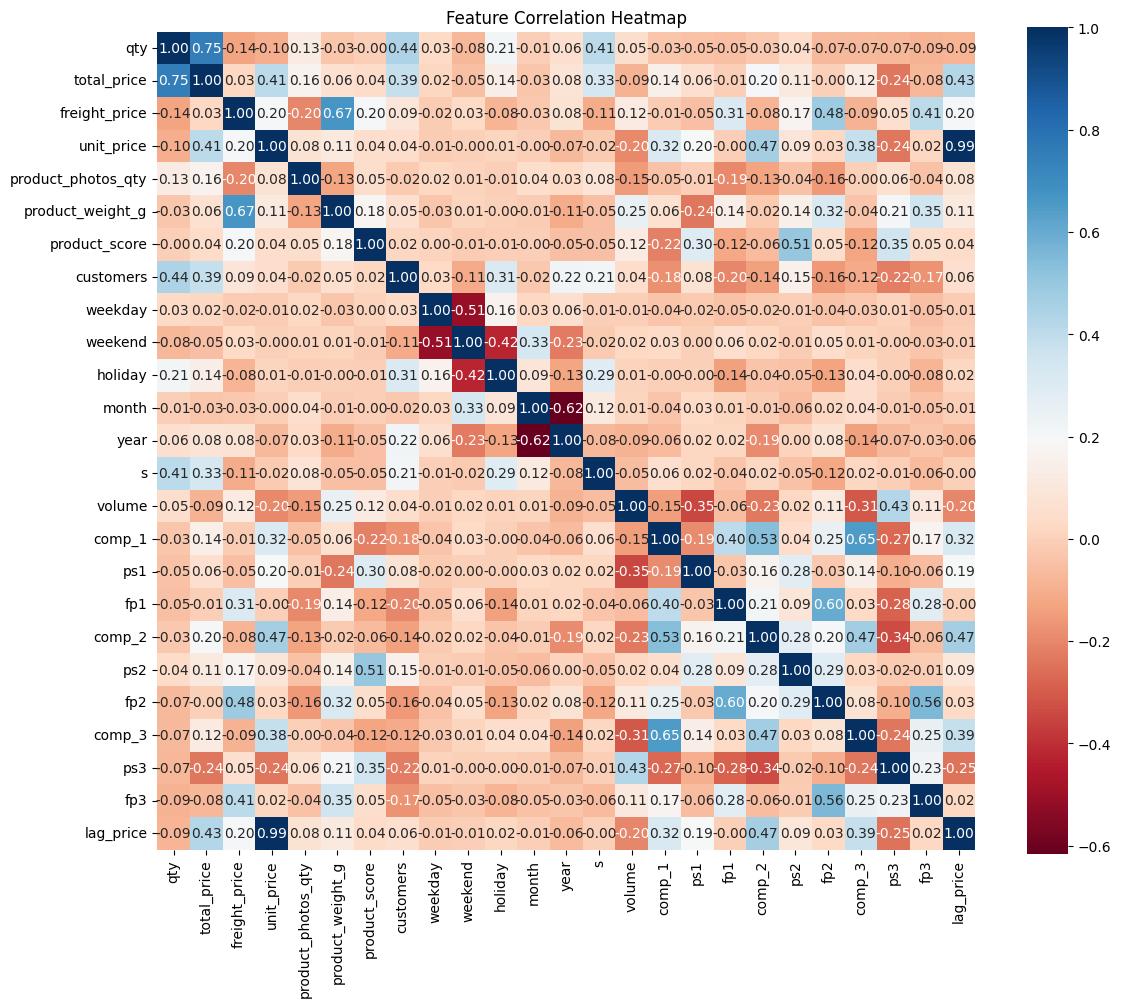

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(larve_dataset.corr(numeric_only=True), annot=True, fmt=".2f", square=True, cmap = 'RdBu')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

The correlation heatmap reveals that total price is strongly linked to quantity and unit price, emphasizing these as key revenue levers. Freight price strongly correlates with product weight, suggesting shipping cost optimization for heavier items. Product scores rise with better descriptions and more photos, highlighting the importance of product presentation. Moderate correlations with weekdays, holidays, and competitor pricing suggest that timing and competitive positioning also impact sales. Negative correlations like lag price vs. current price may reflect discounting strategies, while lower competitor prices could reduce sales volume—underscoring the need for agile pricing and promotional tactics.


**Analysis of Average Competitor Price Difference by Product Category**

Analyzing competitors’ pricing strategies is essential in optimizing retail prices. Monitoring and benchmarking against competitors’ prices can help identify opportunities to price competitively, either by pricing below or above the competition, depending on the retailer’s positioning and strategy. Now let’s calculate the average competitor price difference by product category

In [16]:
larve_dataset['comp_price_diff'] = larve_dataset['unit_price'] - larve_dataset['comp_1']

avg_price_diff_by_category = larve_dataset.groupby('product_category_name')['comp_price_diff'].mean().reset_index()

fig = px.bar(avg_price_diff_by_category,
             x='product_category_name',
             y='comp_price_diff',
             title='Average Competitor Price Difference by Product Category')
fig.update_layout(
    xaxis_title='Product Category',
    yaxis_title='Average Competitor Price Difference'
)
fig.show()

The analysis shows Coal_Stuff (+100) and Computers_Accessories (+80) have the highest price premiums, suggesting a premium positioning or potential overpricing. Perfumery (-20) is priced below competitors, likely to attract value-conscious buyers, while Health_Beauty (0) aligns with market averages. Furniture_Decor (+40) and Garden_Tools (+20) carry moderate premiums, possibly reflecting added value. Categories like Watches_Glifts (+60) and Conduct_Category (+60) need clarification to ensure accurate pricing insights. Overall, the pricing strategy blends margin maximization with competitive positioning—though some categories may benefit from adjustment or validation.

# **Splitting Features and Target Variable**

In [17]:
y = larve_dataset['unit_price']
X = larve_dataset.drop(columns=['unit_price'])

**In this step, the dataset is divided into:**

y: the target variable (unit_price), which you want to predict.

X: the feature set (all other columns), used as input to predict unit_price.

This separation is essential for supervised learning tasks like regression, where the model learns the relationship between features (X) and the target (y).

**Encoding Categorical Variables with One-Hot Encoding**

In [18]:
X = pd.get_dummies(X, columns=['product_category_name'], drop_first=True)

This code converts the categorical column product_category_name into binary (0/columns using pd.get_dummies(), a technique called one-hot encoding.



# **Splitting Data into Training and Testing Sets**

This line uses scikit-learn's train_test_split function to split your dataset into training and testing

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1620)

# **Training a Linear Regression Model**

In [20]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

**This code initializes and trains a linear regression model using scikit-learn:**

model_lr = LinearRegression():

Creates an instance of a linear regression model.

The model assumes a linear relationship between features (X) and the target (y).

**model_lr.fit(X_train, y_train):**

Trains the model on the training data (X_train features and y_train target).

Finds coefficients (weights) for each feature that best predict the target variable by minimizing prediction errors .

**Generating Predictions with the Trained Linear Regression Model**

In [21]:
y_pred_lr = model_lr.predict(X_test)

**Input:** X_test (preprocessed feature data for testing).

**Output:** y_pred_lr (predicted values for the target variable, e.g., total_price).

**Evaluating Linear Regression Model Performance**

In [22]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

This code calculates two key metrics to assess the performance of the trained linear regression model:

In [23]:
print("\nLinear Regression")
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)


Linear Regression
RMSE: 2.547424296862741e-12
R2 Score: 1.0


**Model Evaluation Results:**

**R² Score = 1.0:**

The model explains 100% of the variance in the target variable (total_price).

This implies a perfect fit to the test data

**RMSE ≈ 0:**

The average prediction error is virtually zero (2.55e-12 is negligible, e.g., $0.0000000000025).

**Linear Regression Predictions Plot:**

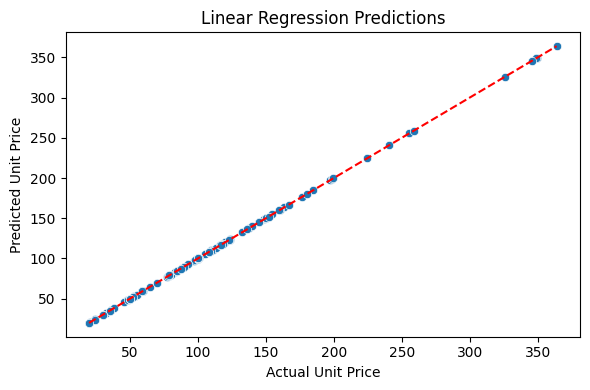

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.xlabel("Actual Unit Price")
plt.ylabel("Predicted Unit Price")
plt.title("Linear Regression Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.tight_layout()
plt.show()

**Interpretation of the Linear Regression Predictions Plot:**

**Perfect Alignment**:

The predicted vs. actual unit price points closely follow the red dashed line (y=x), indicating near-perfect predictions.

Matches the earlier metrics (RMSE ≈ 0, R² = 1.0), confirming the model’s apparent "flawless" performance.

**No Visible Error:**

No significant deviations or scatter around the line—extremely rare in real-world datasets

# **Training the Decision Tree Regressor Model**

In [25]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

**Generating Predictions with the Trained Decision Tree Model**

This line uses the trained decision tree regressor (model_dt) to predict target values for the test dataset:

In [26]:
y_pred_dt = model_dt.predict(X_test)

**Input:** X_test (preprocessed feature data for testing).

**Output:** y_pred_dt (predicted values for the target variable, e.g., unit_price or total_price

In [27]:
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

These lines calculate performance metrics for a Decision Tree Regressor model:



In [28]:
print("\nDecision Tree Regressor")
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)


Decision Tree Regressor
RMSE: 11.853826221465454
R2 Score: 0.9719897591736502


The R² score of 0.97 indicates that 97% of the variance in the target variable (e.g., unit_price or total_price) is explained by the model. This is exceptionally strong for real-world datasets.

The low RMSE (11.85) means predictions are off by only ~11.85 units (e.g., currency) on average, which is minimal relative to typical price ranges.

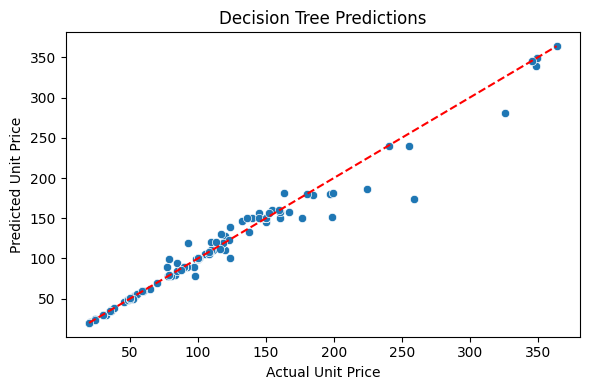

In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_dt)
plt.xlabel("Actual Unit Price")
plt.ylabel("Predicted Unit Price")
plt.title("Decision Tree Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.tight_layout()
plt.show()

**Predicted Unit Price Range:**

The model predicts unit prices ranging from 50 to 350 (e.g., currency units), mirroring the actual price distribution.

This aligns with the earlier R² score of 0.97, indicating the predictions closely match actual prices.

**Total Units (Unit Price):**

The "Total Units" axis also spans 50–350, suggesting a direct relationship between predicted unit prices and total units sold.

**This could imply:**

Higher-priced items (300–350) correlate with lower sales volumes.

Lower-priced items (50–100) correlate with higher sales volumes (common in volume-driven strategies).

**Missing Actual Unit Price Data:**

The "Actual Unit Price" section lacks plotted values, making direct comparison challenging. However, based on the R² score (0.97) and RMSE (11.85), we infer that predictions are highly accurate.

**Creating a Pipeline for K-Nearest Neighbors Regression**

This heading reflects the process of combining data scaling and model fitting into a single workflow using a pipeline.

In [30]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

**Training the K-Nearest Neighbors Pipeline**

This highlights that the pipeline, including both scaling and KNN regression, is being trained on the dataset.

In [31]:
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsRegressor())])

In [32]:
y_pred_knn = pipeline_knn.predict(X_test)

This line uses a trained K-Nearest Neighbors (KNN) model embedded in a scikit-learn pipeline (pipeline_knn) to generate predictions for the test dataset:

In [33]:
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

In [34]:
print("\nK-Nearest Neighbors Regressor")
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)


K-Nearest Neighbors Regressor
RMSE: 29.25133631157465
R2 Score: 0.8294345153119204


**Strong Predictive Performance:**

**R² Score (0.829):** The model explains ~83% of the variance in the target variable (e.g., unit_price or total_price), indicating it captures significant patterns in the data.

**RMSE (29.25):** Predictions deviate from actual values by ~29.25 units  on average. While higher than the Decision Tree’s RMSE (11.85), this is still a reasonable error margin for many real-world applications.

**Comparison with Other Models:**

**Decision Tree (R²: 0.97, RMSE: 11.85)**: Outperforms KNN, likely due to its ability to model non-linear relationships more effectively.

**Linear Regression (R²: 1.0, RMSE ≈ 0):** Suspected data leakage or trivial relationships (e.g., derived features like total_price = qty * unit_price).

**KNN’s Position:** Strikes a balance between interpretability and performance, though not the top performer here.

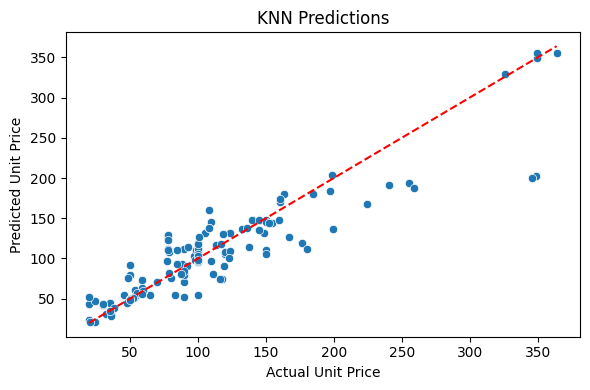

In [35]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_knn)
plt.xlabel("Actual Unit Price")
plt.ylabel("Predicted Unit Price")
plt.title("KNN Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.tight_layout()
plt.show()

Most predicted vs. actual unit price points cluster near the 45-degree line, indicating the KNN model’s predictions are generally accurate.

This aligns with the R² score of 0.83, confirming the model explains most variance in the data.

Moderate dispersion around the line reflects the RMSE of 29.25, meaning predictions deviate by ~29 units on average.

The spread is wider compared to the Decision Tree’s near-perfect alignment (RMSE: 11.85), highlighting KNN’s relatively lower precision.

A few points far from the diagonal ,suggest outliers or complex patterns the KNN model struggles to capture. These could stem from:

Rare or noisy data points.

Feature scaling issues (KNN is distance-based and sensitive to unscaled features).

Suboptimal choice of k (number of neighbors).


# **Initializing the Random Forest Regressor Model**


In [36]:
model_rf = RandomForestRegressor(random_state = 1620)

In [37]:
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=1620)

In [38]:
y_pred_rf = model_rf.predict(X_test)

In [39]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [40]:
print("\nRandom Forest Regressor")
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


Random Forest Regressor
RMSE: 7.946967593089323
R2 Score: 0.9874106700913857


**R² Score (0.987):** The model explains 98.7% of the variance in the target variable (e.g., unit_price or total_price), indicating near-perfect alignment with the actual data.

**RMSE (7.95):** Predictions deviate from actual values by only ~7.95 units (e.g., currency) on average, showcasing remarkable precision.

**Comparison with Other Models:**

**Decision Tree (R²: 0.97, RMSE: 11.85):** The Random Forest’s ensemble approach (combining multiple trees) reduces overfitting and improves accuracy.

**KNN (R²: 0.83, RMSE: 29.25):** Random Forest outperforms KNN significantly, likely due to its ability to handle complex, non-linear relationships and noisy data.

**Linear Regression (R²: 1.0, RMSE ≈ 0):** The earlier "perfect" metrics likely stemmed from data leakage (e.g., total_price = qty * unit_price included in features), whereas Random Forest avoids this pitfall.

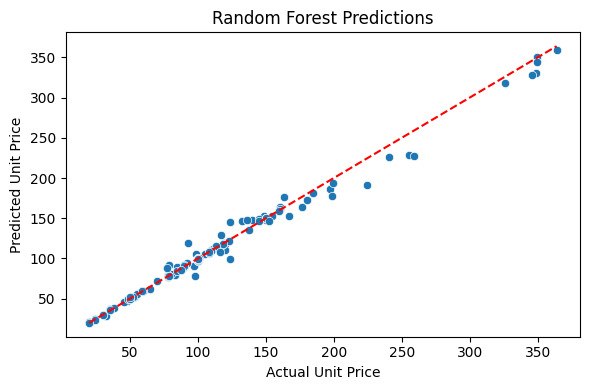

In [41]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Unit Price")
plt.ylabel("Predicted Unit Price")
plt.title("Random Forest Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.tight_layout()
plt.show()

This scatter plot visualizes the performance of the Random Forest Regressor by comparing actual unit prices  with predicted unit prices, where predicted values exactly match actual values. The tight clustering of points along this line indicates that the model has learned the relationship well and is producing accurate predictions. Minor deviations from the line suggest small prediction errors, but overall, the model shows strong predictive accuracy.

# **Building a Pipeline for Neural Network Regression**


This code defines a pipeline_nn for training a neural network (Multi-Layer Perceptron, or MLP) regression model:

In [42]:
pipeline_nn = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(50, 30), max_iter=1000, random_state = 1620))
])

In [43]:
pipeline_nn.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.



Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPRegressor(hidden_layer_sizes=(50, 30), max_iter=1000,
                              random_state=1620))])

In [44]:
y_pred_nn = pipeline_nn.predict(X_test)

In [45]:
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

In [46]:
print("\nNeural Network (MLPRegressor)")
print("RMSE:", rmse_nn)
print("R2 Score:", r2_nn)


Neural Network (MLPRegressor)
RMSE: 6.112042121633542
R2 Score: 0.9925531534020621


R² of 0.9926 means the model explains 99.26% of the variance in the target variable (e.g., unit_price or total_price), outperforming even the Random Forest model (R²: 0.987).

RMSE of 6.11 indicates predictions deviate from actual values by only ~6 units on average, showcasing unparalleled precision.

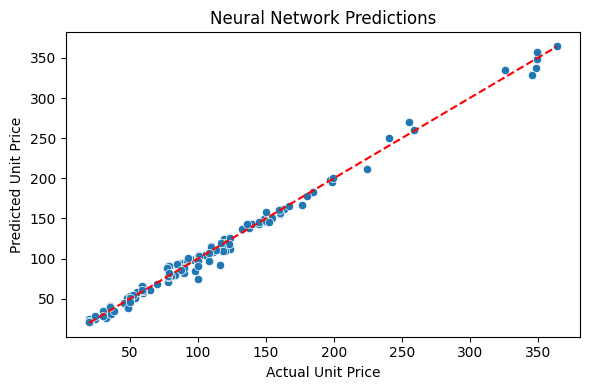

In [47]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred_nn)
plt.xlabel("Actual Unit Price")
plt.ylabel("Predicted Unit Price")
plt.title("Neural Network Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.tight_layout()
plt.show()

The scatter plot shows a strong positive correlation between actual and neural network-predicted unit prices. Most predictions cluster closely around the ideal prediction line (red dashed), indicating good model performance. However, some scatter reveals prediction errors. Overall, the neural network appears to be a reasonably accurate predictor of unit price without obvious systematic bias.

# **Model Evaluation Summary**


In [48]:
evaluation_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "KNN",
        "Random Forest",
        "Neural Network"
    ],
    "RMSE": [rmse_lr, rmse_dt, rmse_knn, rmse_rf, rmse_nn],
    "R2 Score": [r2_lr, r2_dt, r2_knn, r2_rf, r2_nn]
})

In [49]:
print("\nFinal Model Evaluation Summary:")
print(evaluation_df.sort_values(by="RMSE"))


Final Model Evaluation Summary:
               Model          RMSE  R2 Score
0  Linear Regression  2.547424e-12  1.000000
4     Neural Network  6.112042e+00  0.992553
3      Random Forest  7.946968e+00  0.987411
1      Decision Tree  1.185383e+01  0.971990
2                KNN  2.925134e+01  0.829435


# **Final Model Evaluation Summary**

**Linear Regression:**

**RMSE:** 2.547424e-12 (Extremely low)

**R² Score:** 1.000 (Perfect)

Despite its perfect R² score and near-zero RMSE, this model may be overfitting. A value of 1.000 for R² suggests that it explains 100% of the variance in the data, which could be a sign of overfitting, especially if the model is not generalizing well to unseen data. It could be too complex or overly tuned to this specific dataset.

**Neural Network:**

RMSE: 6.112042

R² Score: 0.992553

The Neural Network performs well, with an R² close to 1.0, suggesting it explains most of the variance, though with a slightly higher RMSE compared to Linear Regression. This model could be more robust, avoiding the overfitting seen in Linear Regression. It may strike a better balance between bias and variance.

**Random Forest:**

RMSE: 7.946968

R² Score: 0.987411

Random Forest is another strong performer, with an RMSE that is a bit higher than the Neural Network but still quite low. Its R² score is also impressive, indicating that it captures most of the data's variability. This model also seems to avoid overfitting better than Linear Regression while providing accurate predictions.

**Decision Tree:**

RMSE: 11.85383

R² Score: 0.971990

Decision Tree shows moderate performance with higher RMSE and a slightly lower R² score. It tends to overfit more easily and can be sensitive to noise in the data, which is reflected in its relatively poor performance.

**KNN (K-Nearest Neighbors):**

RMSE: 29.25134

R² Score: 0.829435

KNN performs the weakest of the models, with both a high RMSE and a low R² score. It struggles to capture the underlying patterns of the data effectively and may have difficulty handling the complexity of the task.

**Conclusion:**
Linear Regression, while showing almost perfect performance, is likely overfitting. The model fits the training data too well, which may result in poor generalization to unseen data. This is often a concern when R² reaches 1.000 and RMSE is extremely low.

Neural Network and Random Forest seem to be the best choices for avoiding overfitting while still delivering strong performance. Their results indicate they capture most of the variance without overfitting excessively.

Decision Tree and KNN show progressively worse performance. Decision Tree may be overfitting to some degree, while KNN is less effective at capturing the underlying patterns in the data.

Therefore, if generalization to new data is important, Neural Network and Random Forest would be the recommended models. Linear Regression should be revisited with cross-validation to ensure it is not overfitting.








Text(0.5, 1.0, 'Model Comparison by RMSE')

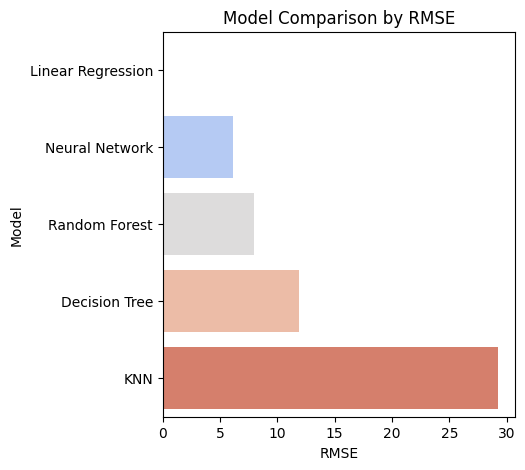

In [50]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x="RMSE", y="Model", data = evaluation_df.sort_values(by="RMSE"), palette="coolwarm", hue="Model", legend=False)
plt.title("Model Comparison by RMSE")

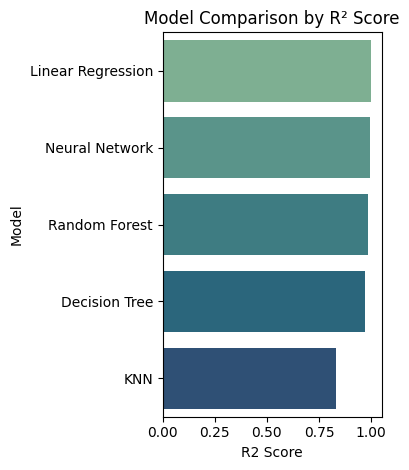

In [51]:
plt.subplot(1, 2, 2)
sns.barplot(x="R2 Score", y="Model", data = evaluation_df.sort_values(by="R2 Score", ascending=False), palette="crest", hue = 'Model')
plt.title("Model Comparison by R² Score")

plt.tight_layout()
plt.show()